In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_train = pd.read_csv("data/train_motion_data.csv")
df_test = pd.read_csv("data/test_motion_data.csv")

In [4]:
# Get norms (magnitudes)
df_train["AccNorm"] = np.linalg.norm((df_train["AccX"], df_train["AccY"], df_train["AccZ"]), axis=0)
df_train["GyroNorm"] = np.linalg.norm((df_train["GyroX"], df_train["GyroY"], df_train["GyroZ"]), axis=0)

df_test["AccNorm"] = np.linalg.norm((df_test["AccX"], df_test["AccY"], df_test["AccZ"]), axis=0)
df_test["GyroNorm"] = np.linalg.norm((df_test["GyroX"], df_test["GyroY"], df_test["GyroZ"]), axis=0)

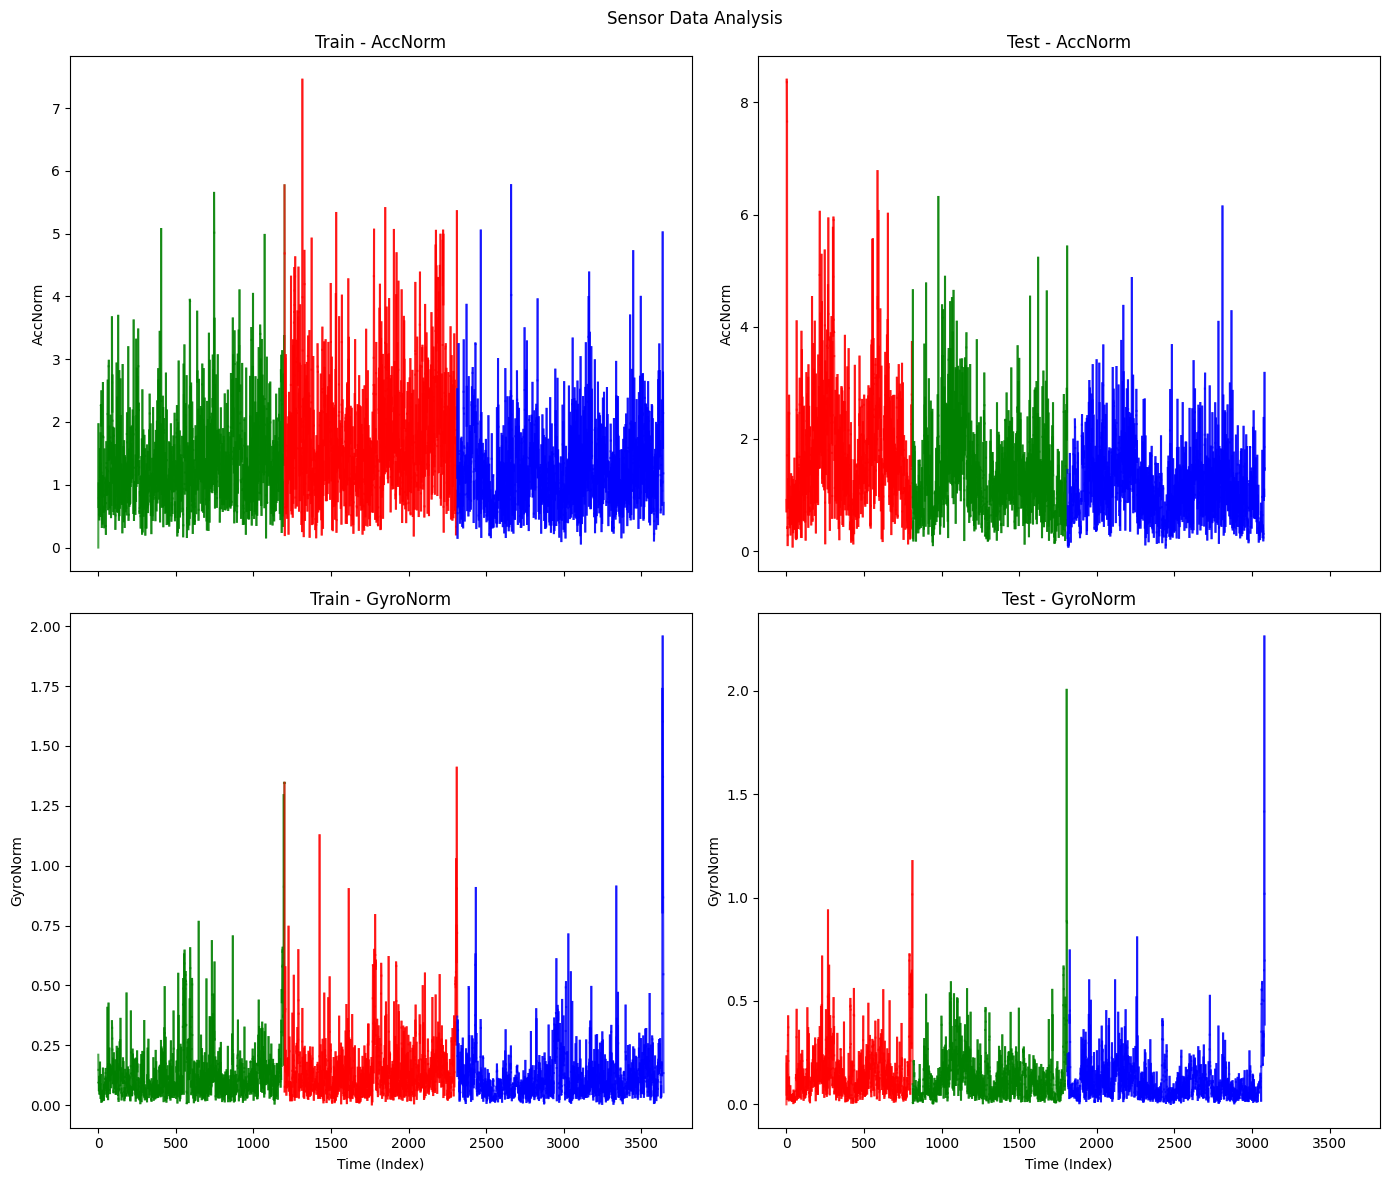

In [5]:
# Analyze signals based on behavior

# Colors for driving behavior
class_colors = {'SLOW': 'blue', 'NORMAL': 'green', 'AGGRESSIVE': 'red'}

# Plot each magnitude with color based on behavior
def plot_with_behavior_color(df, title, feature, ax):
    time_axis = np.arange(len(df))
    behavior_labels = df['Class'].values

    for i in range(len(df) - 1):
        ax.plot(time_axis[i:i+2], df[feature].iloc[i:i+2], 
                color=class_colors.get(behavior_labels[i], "black"), alpha=0.7)
    
    ax.set_title(title)
    ax.set_ylabel(feature.replace("_", " "))
    
# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True)

datasets = {"Train": df_train, "Test": df_test}
features = ["AccNorm", "GyroNorm"]
for i, (label, df) in enumerate(datasets.items()):
    for j, feature in enumerate(features):
        plot_with_behavior_color(df, f"{label} - {feature.replace('_', ' ')}", feature, axes[j, i])

axes[1, 0].set_xlabel("Time (Index)")
axes[1, 1].set_xlabel("Time (Index)")

plt.suptitle("Sensor Data Analysis")
plt.tight_layout()
plt.show()


In [6]:
# Cut off the last ten entries of each Class (30 total)
df_train_drop_normal = df_train[df_train["Class"] == "NORMAL"].index[-10:]
df_train_drop_aggressive = df_train[df_train["Class"] == "AGGRESSIVE"].index[-10:]
df_train_drop_slow = df_train[df_train["Class"] == "SLOW"].index[-10:]

df_train.drop(df_train_drop_normal, inplace=True)
df_train.drop(df_train_drop_aggressive, inplace=True)
df_train.drop(df_train_drop_slow, inplace=True)

In [7]:
# Cut off the last ten entries of each Class (30 total)
df_test_drop_normal = df_test[df_test["Class"] == "NORMAL"].index[-10:]
df_test_drop_aggressive = df_test[df_test["Class"] == "AGGRESSIVE"].index[-10:]
df_test_drop_slow = df_test[df_test["Class"] == "SLOW"].index[-10:]

df_test.drop(df_test_drop_normal, inplace=True)
df_test.drop(df_test_drop_aggressive, inplace=True)
df_test.drop(df_test_drop_slow, inplace=True)

In [8]:
# Make NORMAL and SLOW one class
df_train["Class"] = df_train["Class"].replace("SLOW", "NORMAL")
df_test["Class"] = df_test["Class"].replace("SLOW", "NORMAL")

In [9]:
# Apply sliding window transformation (10s window, 5s stride)
window_size = 20
stride = 10

def create_sliding_windows(df, window_size, stride):
    X_features = []
    y_labels = []

    for start in range(0, len(df) - window_size, stride):
        window = df.iloc[start:start + window_size]
        label = window["Class"].mode()[0]  # Label the window by the mode class

        # Feature extraction
        features = {
            "AccNorm_mean": window["AccNorm"].mean(),
            "AccNorm_std": window["AccNorm"].std(),
            "AccNorm_max": window["AccNorm"].max(),
            "AccNorm_min": window["AccNorm"].min(),
            "GyroNorm_mean": window["GyroNorm"].mean(),
            "GyroNorm_std": window["GyroNorm"].std(),
            "GyroNorm_max": window["GyroNorm"].max(),
            "GyroNorm_min": window["GyroNorm"].min(),
            "AccNorm_jerk": np.mean(np.abs(np.diff(window["AccNorm"]))),  # Mean jerk
            "GyroNorm_jerk": np.mean(np.abs(np.diff(window["GyroNorm"])))  # Mean rotation acc
        }

        X_features.append(features)
        y_labels.append(label)

    return pd.DataFrame(X_features), np.array(y_labels)

X_train, y_train = create_sliding_windows(df_train, window_size, stride)
X_test, y_test = create_sliding_windows(df_test, window_size, stride)

data_overview = pd.DataFrame({
    "Before Windowing (Train)": train_class_counts,
    "After Windowing (Train)": train_class_counts_after_windowing,
    "Before Windowing (Test)": test_class_counts,
    "After Windowing (Test)": test_class_counts_after_windowing
})
data_overview

,Before Windowing (Train),After Windowing (Train),Before Windowing (Test),After Windowing (Test)
NORMAL,2511,249,2250,224
AGGRESSIVE,1103,111,804,80


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

classification_results = classification_report(y_test, y_pred, output_dict=True)

In [17]:
classification_df = pd.DataFrame(classification_results).T
classification_df

,precision,recall,f1-score,support
AGGRESSIVE,0.616438,0.562500,0.588235,80.000000
NORMAL,0.848485,0.875000,0.861538,224.000000
accuracy,0.792763,0.792763,0.792763,0.792763
macro avg,0.732462,0.718750,0.724887,304.000000
weighted avg,0.787420,0.792763,0.789617,304.000000


In [18]:
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)
feature_importances

,Feature,Importance
0,AccNorm_mean,0.246351
1,AccNorm_std,0.133921
2,AccNorm_max,0.114678
8,AccNorm_jerk,0.097604
7,GyroNorm_min,0.075742
3,AccNorm_min,0.072063
6,GyroNorm_max,0.070194
4,GyroNorm_mean,0.067525
9,GyroNorm_jerk,0.062509
5,GyroNorm_std,0.059413


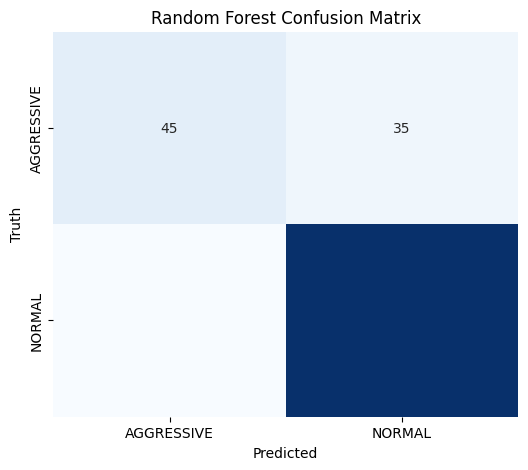

In [19]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix, index=np.unique(y_test), columns=np.unique(y_test))
conf_matrix_df

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler

label_mapping = {"NORMAL": 0, "AGGRESSIVE": 1}
df_train["Class"] = df_train["Class"].map(label_mapping)
df_test["Class"] = df_test["Class"].map(label_mapping)

feature_cols = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]
train_features = df_train[feature_cols]
test_features = df_test[feature_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)

sequence_length = 20

# Convert data into sequences
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, df_train["Class"].values, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, df_test["Class"].values, sequence_length)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['recall'])
history = model.fit(X_train_seq, y_train_seq, epochs=15, batch_size=32, validation_data=(X_test_seq, y_test_seq))

y_pred_seq = model.predict(X_test_seq)
y_pred_labels = (y_pred_seq > 0.5).astype(int).flatten()  # Convert probabilities to class labels

classification_df_lstm = pd.DataFrame(classification_rep_lstm).T
classification_df_lstm

Epoch 1/15


/Users/sidneyma/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: nan - recall: 0.0204 - val_loss: nan - val_recall: 0.0000e+00
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: nan - recall: 0.0000e+00 - val_loss: nan - val_recall: 0.0000e+00
Epoch 9

,precision,recall,f1-score,support
NORMAL,0.887894,0.837778,0.862108,2250.000000
AGGRESSIVE,0.599341,0.696429,0.644248,784.000000
accuracy,0.801252,0.801252,0.801252,0.801252
macro avg,0.743618,0.767103,0.753178,3034.000000
weighted avg,0.813331,0.801252,0.805812,3034.000000


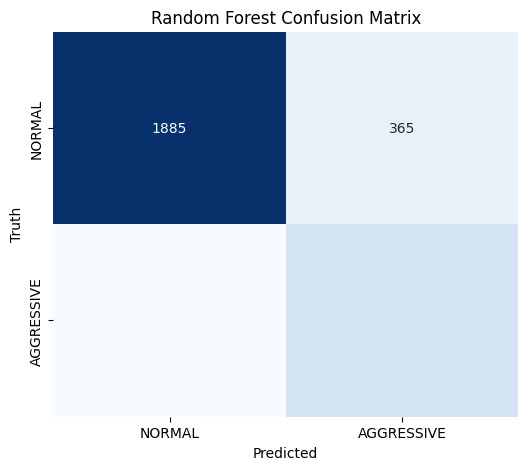

In [22]:
conf_matrix_lstm_df = pd.DataFrame(conf_matrix_lstm, index=["NORMAL", "AGGRESSIVE"], columns=["NORMAL", "AGGRESSIVE"])
conf_matrix_lstm_df

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_lstm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Random Forest Confusion Matrix")
plt.show()